Data-Driven Analysis of Traffic Crash Causes

1.  INTRODUCTION


Traffic accidents remain a significant public safety challenge in urban environments, leading to injuries, fatalities, and economic losses. Although large volumes of crash data are collected, it is often difficult for city authorities to extract clear insights about the underlying causes of accidents and the conditions in which they occur.

This project uses integrated crash, vehicle, and people-level data to identify the key factors associated with injury-related crashes.

By applying machine learning techniques, this project aims to:

Predict whether a crash results in injury or no injury
Identify the most influential contributing factors
Translate findings into actionable safety recommendations

Data Sources:
1. Crashes dataset → accident-level details
2. Vehicles dataset → vehicle-level characteristics
3. People dataset → driver/passenger attributes




2.  BUSINESS UNDERSTANDING

Stakeholder

1. City transportation authority 
2. Road Safety Agencies
3. Urban Planners
4. Emergency Response Teams 

Key Business Questions

This project is designed to answer the following questions:


1. What factors most strongly contribute to injury-related crashes?

2. How do weather, lighting, and road conditions affect crash severity?

3. Do certain vehicle types or manufacturing years correlate with higher crash severity?


3.  DATA LOADING 

Data Sources

In [61]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [4]:
#Read Datasets
crashes=pd.read_csv("Crashes.csv")
people=pd.read_csv("People.csv")
vehicle=pd.read_csv("Vehicles.csv")


c:\Users\user\anaconda3\envs\learn-env\lib\site-packages\IPython\core\interactiveshell.py:3145: DtypeWarning: Columns (10) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
c:\Users\user\anaconda3\envs\learn-env\lib\site-packages\IPython\core\interactiveshell.py:3145: DtypeWarning: Columns (28) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
c:\Users\user\anaconda3\envs\learn-env\lib\site-packages\IPython\core\interactiveshell.py:3145: DtypeWarning: Columns (20,39,40,41,43,47,48,49,52,54,57,58,60,70) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


4.  DATA UNDERSTANDING

In [5]:
print("CRASHES DATASET")
print(crashes.shape)
crashes.info()
print(crashes.columns)

print("\nVEHICLES DATASET")
print(vehicle.shape)
vehicle.info()
print(vehicle.columns)

print("\nPEOPLE DATASET")
print(people.shape)
people.info()
print(people.columns)

CRASHES DATASET
(1048575, 48)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 48 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   CRASH_RECORD_ID                1048575 non-null  object 
 1   CRASH_DATE_EST_I               75848 non-null    object 
 2   CRASH_DATE                     1048575 non-null  object 
 3   POSTED_SPEED_LIMIT             1048575 non-null  int64  
 4   TRAFFIC_CONTROL_DEVICE         1048575 non-null  object 
 5   DEVICE_CONDITION               1048575 non-null  object 
 6   WEATHER_CONDITION              1048575 non-null  object 
 7   LIGHTING_CONDITION             1048575 non-null  object 
 8   FIRST_CRASH_TYPE               1048575 non-null  object 
 9   TRAFFICWAY_TYPE                1048575 non-null  object 
 10  LANE_CNT                       197585 non-null   object 
 11  ALIGNMENT                      1048575 non-nul

DATA CLEANING

A. Crashes Dataset

In [6]:
crashes.isnull().sum().sort_values(ascending=False)

WORKERS_PRESENT_I                1047134
DOORING_I                        1045272
WORK_ZONE_TYPE                   1044294
WORK_ZONE_I                      1042956
PHOTOS_TAKEN_I                   1033512
STATEMENTS_TAKEN_I               1023302
NOT_RIGHT_OF_WAY_I               1001739
CRASH_DATE_EST_I                  972727
LANE_CNT                          850990
INTERSECTION_RELATED_I            807275
HIT_AND_RUN_I                     719510
REPORT_TYPE                        35275
LOCATION                            8054
LATITUDE                            8054
LONGITUDE                           8054
MOST_SEVERE_INJURY                  2276
INJURIES_UNKNOWN                    2261
INJURIES_INCAPACITATING             2261
INJURIES_NON_INCAPACITATING         2261
INJURIES_NO_INDICATION              2261
INJURIES_REPORTED_NOT_EVIDENT       2261
INJURIES_TOTAL                      2261
INJURIES_FATAL                      2261
BEAT_OF_OCCURRENCE                     5
STREET_DIRECTION

1. Fixing Data Types 

In [27]:
crashes["CRASH_DATE"] = pd.to_datetime(crashes["CRASH_DATE"], errors="coerce")



2. Handling Missing Values

In [28]:
crashes["INJURIES_TOTAL"]=crashes["INJURIES_TOTAL"].fillna(0)


3. Removing Duplicates

In [29]:
crashes = crashes.drop_duplicates(subset=["CRASH_RECORD_ID"])

4. Dropping columns with many missing Values

In [30]:
crashes.isnull().sum().sort_values(ascending=False)

WORKERS_PRESENT_I                1039097
DOORING_I                        1037222
WORK_ZONE_TYPE                   1036289
WORK_ZONE_I                      1034964
PHOTOS_TAKEN_I                   1025530
STATEMENTS_TAKEN_I               1015420
NOT_RIGHT_OF_WAY_I                994000
CRASH_DATE_EST_I                  965148
LANE_CNT                          843823
INTERSECTION_RELATED_I            800543
HIT_AND_RUN_I                     712992
REPORT_TYPE                        35092
MOST_SEVERE_INJURY                  2258
INJURIES_UNKNOWN                    2243
INJURIES_NO_INDICATION              2243
INJURIES_REPORTED_NOT_EVIDENT       2243
INJURIES_NON_INCAPACITATING         2243
INJURIES_FATAL                      2243
INJURIES_INCAPACITATING             2243
BEAT_OF_OCCURRENCE                     3
STREET_DIRECTION                       1
ALIGNMENT                              0
TRAFFICWAY_TYPE                        0
ROADWAY_SURFACE_COND                   0
LOCATION        

In [31]:
crashes_keep=[
    "CRASH_RECORD_ID",  
    "PRIM_CONTRIBUTORY_CAUSE",
    "DEVICE_CONDITION",
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "ROADWAY_SURFACE_COND",
    "ROAD_DEFECT",
    "TRAFFIC_CONTROL_DEVICE",
    "CRASH_HOUR",
    "CRASH_DAY_OF_WEEK",
    "CRASH_MONTH",
    "POSTED_SPEED_LIMIT",
    "CRASH_TYPE",
    "INJURIES_TOTAL",
    
]
crashes_clean = crashes[crashes_keep].copy()

B. Vehicle Dataset

1. Dropping columns with many missing Values

In [13]:
vehicle = vehicle[[
    'CRASH_RECORD_ID',
    'UNIT_TYPE',
    'MAKE',
    'VEHICLE_YEAR',
    'MANEUVER',
    'VEHICLE_TYPE'
]]

In [33]:
print(vehicle["VEHICLE_YEAR"].value_counts(dropna=False))

2017.0    58116
2015.0    55538
2018.0    55184
2019.0    53596
2016.0    52905
          ...  
1938.0        1
1919.0        1
1907.0        1
1960.0        1
1950.0        1
Name: VEHICLE_YEAR, Length: 80, dtype: int64


2. Fixing Datatype and Removing unrealistic values 

In [34]:
vehicle["VEHICLE_YEAR"] = pd.to_numeric(vehicle["VEHICLE_YEAR"], errors="coerce")
vehicle = vehicle[(vehicle["VEHICLE_YEAR"] <= 2026) & (vehicle["VEHICLE_YEAR"] >= 1900)]



3. Standardizing categories 

In [35]:
# Visulaizing all unique values in UNIT_TYPE and MANEUVER
print(vehicle["UNIT_TYPE"].value_counts(dropna=False))
print(vehicle["MANEUVER"].value_counts(dropna=False))

DRIVER        731411
PARKED        132547
DRIVERLESS      5454
OTHER            273
UNKNOWN            1
Name: UNIT_TYPE, dtype: int64
STRAIGHT AHEAD        428344
STATIONARY            137713
INTERSECTION MOVES     95508
NORMAL DRIVING         67159
LANE MOVEMENT          58056
OTHER                  43610
BACKING                31752
LOSS OF CONTROL         7543
UNKNOWN                    1
Name: MANEUVER, dtype: int64


In [17]:
vehicle['UNIT_TYPE'] = vehicle['UNIT_TYPE'].replace({
    'NON-MOTOR VEHICLE': 'OTHER',
    'NON-CONTACT VEHICLE': 'OTHER',
    'DISABLED VEHICLE': 'OTHER',
    'EQUESTRIAN': 'OTHER',
    'BICYCLE':'CYCLIST'
})
vehicle["MANEUVER"] = vehicle["MANEUVER"].replace({
    "SLOW/STOP IN TRAFFIC":               "NORMAL DRIVING",
    "SLOW/STOP - LEFT TURN":              "NORMAL DRIVING",
    "SLOW/STOP - RIGHT TURN":             "NORMAL DRIVING",
    "SLOW/STOP - LOAD/UNLOAD":            "NORMAL DRIVING",
    "PARKED IN TRAFFIC LANE":             "STATIONARY",
    "LEAVING TRAFFIC LANE TO PARK":       "LANE MOVEMENT",
    "ENTERING TRAFFIC LANE FROM PARKING": "LANE MOVEMENT",
    "ENTER FROM DRIVE/ALLEY":             "STATIONARY",
    "STARTING IN TRAFFIC":                "NORMAL DRIVING",
    "MERGING":                            "LANE MOVEMENT",
    "PARKED":                             "STATIONARY",
    "UNKNOWN/NA":                          "OTHER",
    "TURNING LEFT":                       "INTERSECTION MOVES",
    "TURNING RIGHT":                      "INTERSECTION MOVES",
    "PASSING/OVERTAKING":                 "LANE MOVEMENT",
    "CHANGING LANES":                     "LANE MOVEMENT",
    "U-TURN":                             "INTERSECTION MOVES",
    "AVOIDING VEHICLES/OBJECTS":          "LOSS OF CONTROL",
    "SKIDDING/CONTROL LOSS":              "LOSS OF CONTROL",
    "DRIVING WRONG WAY":                  "LOSS OF CONTROL",
    "NEGOTIATING A CURVE":                "INTERSECTION MOVES",
    "TURNING ON RED":                     "INTERSECTION MOVES",
    "DRIVERLESS":                         "OTHER",
    "DISABLED":                           "OTHER",
    "DIVERGING":                          "LANE MOVEMENT",

})

4. Handling missing values 

In [36]:
vehicle["UNIT_TYPE"] = vehicle["UNIT_TYPE"].fillna("UNKNOWN")
vehicle["MANEUVER"] = vehicle["MANEUVER"].fillna("UNKNOWN")
vehicle["VEHICLE_TYPE"] = vehicle["VEHICLE_TYPE"].fillna("UNKNOWN")
vehicle["MAKE"] = vehicle["MAKE"].fillna("UNKNOWN")

C. PEOPLE DATASET

1. Dropping columns with many missing Values

In [37]:
people = people[[
    "CRASH_RECORD_ID",
    "PERSON_TYPE",
    "SEX",
    "AGE",
    "SAFETY_EQUIPMENT",
    "AIRBAG_DEPLOYED"
]]

2. Standardizing categories 

In [38]:
print(people["PERSON_TYPE"].value_counts(dropna=False))
print(people["SAFETY_EQUIPMENT"].value_counts(dropna=False))
print(people["AIRBAG_DEPLOYED"].value_counts(dropna=False))

DRIVER        594395
PASSENGER     127768
PEDESTRIAN     12252
CYCLIST         7708
OTHER            586
Name: PERSON_TYPE, dtype: int64
PROTECTED        367510
UNKNOWN          326131
NOT PROTECTED     43068
CHILD SAFETY       5551
IMPROPER USE        285
OTHER               164
Name: SAFETY_EQUIPMENT, dtype: int64
NO                335835
NOT APPLICABLE    269486
UNKNOWN            69325
YES                68063
Name: AIRBAG_DEPLOYED, dtype: int64


In [21]:
people["PERSON_TYPE"] = people["PERSON_TYPE"].replace({
    "NON-MOTOR VEHICLE": "OTHER",
    "BICYCLE": "CYCLIST",
    "NON-CONTACT VEHICLE": "OTHER"
})

people["SAFETY_EQUIPMENT"] = people["SAFETY_EQUIPMENT"].replace({
    "SAFETY BELT USED": "PROTECTED",
    "CHILD RESTRAINT USED": "PROTECTED",
    "BOOSTER SEAT": "PROTECTED",
    "HELMET USED": "PROTECTED",
    "BICYCLE HELMET (PEDACYCLIST INVOLVED ONLY)": "PROTECTED",
    "DOT COMPLIANT MOTORCYCLE HELMET": "PROTECTED",

    "NONE PRESENT": "NOT PROTECTED",
    "SAFETY BELT NOT USED": "NOT PROTECTED",
    "HELMET NOT USED": "NOT PROTECTED",
    "CHILD RESTRAINT NOT USED": "NOT PROTECTED",
    "NOT DOT COMPLIANT MOTORCYCLE HELMET": "NOT PROTECTED",

    "SHOULD/LAP BELT USED IMPROPERLY": "IMPROPER USE",
    "CHILD RESTRAINT USED IMPROPERLY": "IMPROPER USE",

    "CHILD RESTRAINT - FORWARD FACING": "CHILD SAFETY",
    "CHILD RESTRAINT - REAR FACING": "CHILD SAFETY",
    "CHILD RESTRAINT - TYPE UNKNOWN": "CHILD SAFETY",

    "WHEELCHAIR": "OTHER",
    "STRETCHER": "OTHER",
    "USAGE UNKNOWN": "UNKNOWN"
})


In [39]:
people["SAFETY_EQUIPMENT"] = people["SAFETY_EQUIPMENT"].replace({
    "SAFETY BELT USED": "PROTECTED",
    "CHILD RESTRAINT USED": "PROTECTED",
    "BOOSTER SEAT": "PROTECTED",
    "HELMET USED": "PROTECTED",
    "BICYCLE HELMET (PEDACYCLIST INVOLVED ONLY)": "PROTECTED",
    "DOT COMPLIANT MOTORCYCLE HELMET": "PROTECTED",

    "NONE PRESENT": "NOT PROTECTED",
    "SAFETY BELT NOT USED": "NOT PROTECTED",
    "HELMET NOT USED": "NOT PROTECTED",
    "CHILD RESTRAINT NOT USED": "NOT PROTECTED",
    "NOT DOT COMPLIANT MOTORCYCLE HELMET": "NOT PROTECTED",

    "SHOULD/LAP BELT USED IMPROPERLY": "IMPROPER USE",
    "CHILD RESTRAINT USED IMPROPERLY": "IMPROPER USE",

    "CHILD RESTRAINT - FORWARD FACING": "CHILD SAFETY",
    "CHILD RESTRAINT - REAR FACING": "CHILD SAFETY",
    "CHILD RESTRAINT - TYPE UNKNOWN": "CHILD SAFETY",

    "WHEELCHAIR": "OTHER",
    "STRETCHER": "OTHER",
    "USAGE UNKNOWN": "UNKNOWN"
})

people["AIRBAG_DEPLOYED"] = people["AIRBAG_DEPLOYED"].replace({
    "DEPLOYED, FRONT": "YES",
    "DEPLOYED, SIDE": "YES",
    "DEPLOYED, COMBINATION": "YES",
    "DEPLOYED OTHER (KNEE, AIR, BELT, ETC.)": "YES",
    "NaN": "UNKNOWN",

    "DID NOT DEPLOY": "NO",

    "NOT APPLICABLE": "NOT APPLICABLE",

    "DEPLOYMENT UNKNOWN": "UNKNOWN"
})

3. Fixing Data type 

In [40]:
print(people["AGE"].value_counts(dropna=False))


28.0     20217
27.0     20153
29.0     19951
26.0     19915
25.0     19876
         ...  
107.0        2
110.0        2
104.0        2
108.0        2
109.0        1
Name: AGE, Length: 111, dtype: int64


In [41]:
people["AGE"] = pd.to_numeric(people["AGE"], errors="coerce")
people = people[(people["AGE"] >= 0) & (people["AGE"] <= 110)]

4. Handling Missing values

In [42]:
people["PERSON_TYPE"] = people["PERSON_TYPE"].fillna("UNKNOWN")
people["SEX"] = people["SEX"].fillna("UNKNOWN")
people["SAFETY_EQUIPMENT"] = people["SAFETY_EQUIPMENT"].fillna("UNKNOWN")
people["AIRBAG_DEPLOYED"] = people["AIRBAG_DEPLOYED"].fillna("UNKNOWN")

D. AGGREGATION


In [43]:
vehicle_crash_level = vehicle.groupby('CRASH_RECORD_ID').agg({
    'VEHICLE_TYPE': lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN',
    'MAKE': lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN',
    'VEHICLE_YEAR': 'median',
    'UNIT_TYPE': lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN',
    'MANEUVER': lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN'
}).reset_index()

people_crash_level = people.groupby("CRASH_RECORD_ID").agg({
    "PERSON_TYPE": lambda x: x.mode()[0] if not x.mode().empty else "UNKNOWN",
    "SEX": lambda x: x.mode()[0] if not x.mode().empty else "UNKNOWN",
    "AGE": "median",
    "SAFETY_EQUIPMENT": lambda x: x.mode()[0] if not x.mode().empty else "UNKNOWN",
    "AIRBAG_DEPLOYED": lambda x: x.mode()[0] if not x.mode().empty else "UNKNOWN"
}).reset_index()

E. MERGING 

In [44]:
merged_data = crashes_clean.copy()
merged_data = crashes_clean.merge(vehicle_crash_level, on="CRASH_RECORD_ID", how="left")
merged_data = merged_data.merge(people_crash_level, on="CRASH_RECORD_ID", how="left")

1. Handling missing after merging

In [45]:
# Numeric
merged_data["VEHICLE_YEAR"] = pd.to_numeric(merged_data["VEHICLE_YEAR"], errors="coerce")
merged_data["AGE"] = pd.to_numeric(merged_data["AGE"], errors="coerce")

merged_data["VEHICLE_AGE"] = 2026 - merged_data["VEHICLE_YEAR"]

merged_data["VEHICLE_AGE"] = merged_data["VEHICLE_AGE"].fillna(merged_data["VEHICLE_AGE"].median())
merged_data["AGE"] = merged_data["AGE"].fillna(merged_data["AGE"].median())


In [46]:
print(merged_data["CRASH_TYPE"].value_counts(dropna=False))

NO INJURY / DRIVE AWAY              758115
INJURY AND / OR TOW DUE TO CRASH    282406
Name: CRASH_TYPE, dtype: int64


EDA

Plot 1: Crash Frequency by Hour

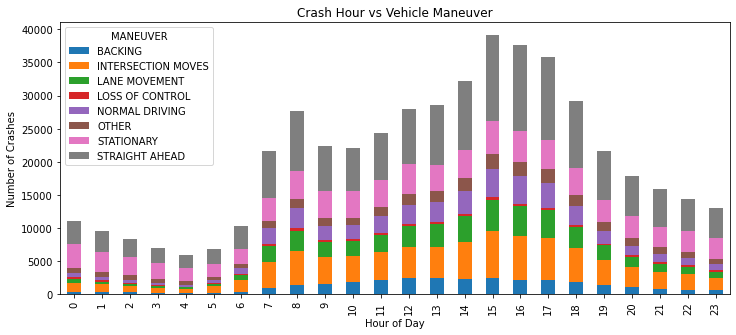

In [ ]:
hour_maneuver = merged_data.groupby(['CRASH_HOUR', 'MANEUVER']).size().unstack(fill_value=0)

hour_maneuver.plot(kind='bar', stacked=True, figsize=(12,5))

plt.xlabel("Hour of Day")
plt.ylabel("Number of Crashes")
plt.title("Crash Hour vs Vehicle Maneuver")

plt.show()

Plot 2: Top 10 Contributory Causes

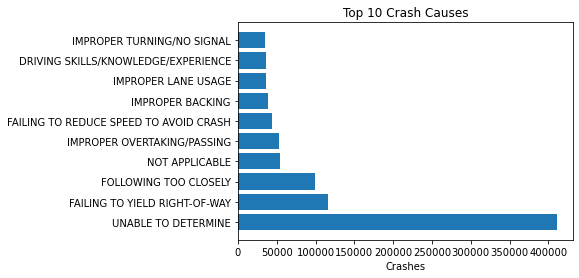

In [ ]:
top5 = merged_data['PRIM_CONTRIBUTORY_CAUSE'].value_counts().head(10).sort

plt.barh(top5.index, top5.values)
plt.title("Top 10 Crash Causes")
plt.xlabel("Crashes")

plt.show()

Plot 3:Target Variable Distribution


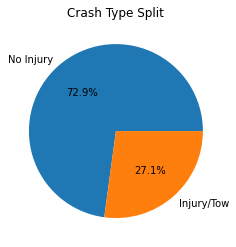

In [ ]:
counts = merged_data['CRASH_TYPE'].value_counts()

plt.pie(counts.values, labels=['No Injury', 'Injury/Tow'], autopct='%1.1f%%')

plt.title("Crash Type Split")

plt.show()


MODELLING

1. Preparing X and y

In [48]:
y = merged_data["CRASH_TYPE"].map({
    "NO INJURY / DRIVE AWAY": 0,
    "INJURY AND / OR TOW DUE TO CRASH": 1
})
X = merged_data.drop(columns=["CRASH_TYPE","CRASH_RECORD_ID","VEHICLE_YEAR"])
X = X.drop(columns=["INJURIES_TOTAL"])

2. Encode Text columns

In [49]:
cat_cols = X.select_dtypes(include="object").columns.tolist()


for col in cat_cols:
    X[col] = X[col].fillna("UNKNOWN")             # fill missing
    X[col] = X[col].astype("category").cat.codes  # encode to numbers

3. Split Data

In [50]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

4. Balancing Training Data

In [51]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

5. Training 

In [53]:

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(class_weight='balanced', random_state=42)

EVALUATION

In [54]:
y_prob = model.predict_proba(X_test)[:, 1]
threshold = 0.52
y_pred = (y_prob >= threshold).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["No Injury", "Injury/Tow"]))

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(f"                    Predicted No Injury   Predicted Injury")
print(f"Actual No Injury        {cm[0][0]:>10,}         {cm[0][1]:>10,}")
print(f"Actual Injury           {cm[1][0]:>10,}         {cm[1][1]:>10,}")


Classification Report:
              precision    recall  f1-score   support

   No Injury       0.81      0.81      0.81    151624
  Injury/Tow       0.49      0.49      0.49     56481

    accuracy                           0.72    208105
   macro avg       0.65      0.65      0.65    208105
weighted avg       0.72      0.72      0.72    208105

Confusion Matrix:
                    Predicted No Injury   Predicted Injury
Actual No Injury           122,783             28,841
Actual Injury               28,922             27,559


In [55]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

CRASH_HOUR                 0.140652
PRIM_CONTRIBUTORY_CAUSE    0.128169
CRASH_MONTH                0.118110
CRASH_DAY_OF_WEEK          0.085735
VEHICLE_AGE                0.058405
POSTED_SPEED_LIMIT         0.048929
AGE                        0.047956
LIGHTING_CONDITION         0.045571
MAKE                       0.043083
AIRBAG_DEPLOYED            0.033171
dtype: float64


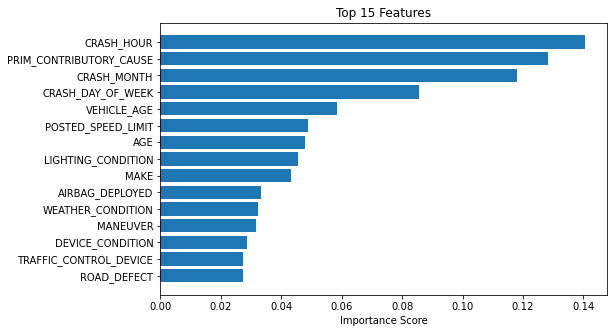

Top 10 features:


CRASH_HOUR                 0.140652
PRIM_CONTRIBUTORY_CAUSE    0.128169
CRASH_MONTH                0.118110
CRASH_DAY_OF_WEEK          0.085735
VEHICLE_AGE                0.058405
POSTED_SPEED_LIMIT         0.048929
AGE                        0.047956
LIGHTING_CONDITION         0.045571
MAKE                       0.043083
AIRBAG_DEPLOYED            0.033171
dtype: float64

In [81]:
# Feature importance
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_n = feature_importance.head(15)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(top_n.index[::-1], top_n.values[::-1])

plt.xlabel("Importance Score")
plt.title("Top 15 Features")

plt.show()

# Display top 10
print("Top 10 features:")
display(feature_importance.head(10))

INSIGHTS

- Most crashes result in no injury
- Environmental conditions strongly affect crash severity
- Human behavior and acivity pattern is a major contributing factor

CONCLUSION

The Random Forest model achieves 72% accuracy.

However, injury prediction recall is lower (0.49), meaning further improvement is needed for real-world deployment.

Future improvements should include:
- Advanced models 
- More behavioral features
- Better traffic and speed data